In [1]:
#STEP 1: Imports
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix


In [2]:
#STEP 2: Paths & Parameters
DATASET_DIR = r"Downloads/Face_dataset/train/"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS_STAGE1 = 10
EPOCHS_STAGE2 = 15


In [3]:
#STEP 3:  CORRECT PREPROCESSING + AUGMENTATION
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,

    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)


In [4]:
#STEP 4: Generators
train_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())
NUM_CLASSES = len(class_names)

print("Classes:", class_names)


Found 1201 images belonging to 5 classes.
Found 298 images belonging to 5 classes.
Classes: ['acne', 'eksim', 'herpes', 'panu', 'rosacea']


In [6]:
#STEP 5: Build Model (STAGE 1)
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False


In [8]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax")
])


In [9]:
#STEP 6: Compile (IMPORTANT LR)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [10]:
#STEP 7: TRAIN – STAGE 1 (YOU WILL SEE JUMP)
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE1
)


Epoch 1/10
76/76 [==============================] - 76s 859ms/step - loss: 1.4836 - accuracy: 0.5304 - val_loss: 1.0598 - val_accuracy: 0.6342
Epoch 2/10
76/76 [==============================] - 63s 823ms/step - loss: 0.8249 - accuracy: 0.7211 - val_loss: 0.8728 - val_accuracy: 0.6812
Epoch 3/10
76/76 [==============================] - 63s 833ms/step - loss: 0.6928 - accuracy: 0.7602 - val_loss: 0.8744 - val_accuracy: 0.6678
Epoch 4/10
76/76 [==============================] - 63s 826ms/step - loss: 0.5654 - accuracy: 0.7977 - val_loss: 0.7975 - val_accuracy: 0.7081
Epoch 5/10
76/76 [==============================] - 62s 817ms/step - loss: 0.5399 - accuracy: 0.8185 - val_loss: 0.9335 - val_accuracy: 0.7215
Epoch 6/10
76/76 [==============================] - 63s 823ms/step - loss: 0.4783 - accuracy: 0.8460 - val_loss: 0.8484 - val_accuracy: 0.7181
Epoch 7/10
76/76 [==============================] - 63s 822ms/step - loss: 0.4134 - accuracy: 0.8543 - val_loss: 0.7922 - val_accuracy: 0.6980

In [11]:
#STEP 8: FINE TUNING (STAGE 2)
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False


In [12]:
#STEP 9: Recompile (LOW LR)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [13]:
#STEP 10: TRAIN – STAGE 2
callbacks = [
    EarlyStopping(patience=4, restore_best_weights=True),
    ReduceLROnPlateau(patience=2, factor=0.3)
]

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE2,
    callbacks=callbacks
)


Epoch 1/15
76/76 [==============================] - 89s 1s/step - loss: 0.6779 - accuracy: 0.7727 - val_loss: 0.9584 - val_accuracy: 0.7013 - lr: 1.0000e-04
Epoch 2/15
76/76 [==============================] - 73s 964ms/step - loss: 0.4454 - accuracy: 0.8393 - val_loss: 0.8822 - val_accuracy: 0.7181 - lr: 1.0000e-04
Epoch 3/15
76/76 [==============================] - 73s 955ms/step - loss: 0.3603 - accuracy: 0.8743 - val_loss: 0.9809 - val_accuracy: 0.7047 - lr: 1.0000e-04
Epoch 4/15
76/76 [==============================] - 72s 945ms/step - loss: 0.3297 - accuracy: 0.8876 - val_loss: 0.7796 - val_accuracy: 0.7617 - lr: 1.0000e-04
Epoch 5/15
76/76 [==============================] - 72s 949ms/step - loss: 0.2630 - accuracy: 0.9109 - val_loss: 0.8598 - val_accuracy: 0.7450 - lr: 1.0000e-04
Epoch 6/15
76/76 [==============================] - 74s 968ms/step - loss: 0.2241 - accuracy: 0.9192 - val_loss: 0.9675 - val_accuracy: 0.7282 - lr: 1.0000e-04
Epoch 7/15
76/76 [=========================

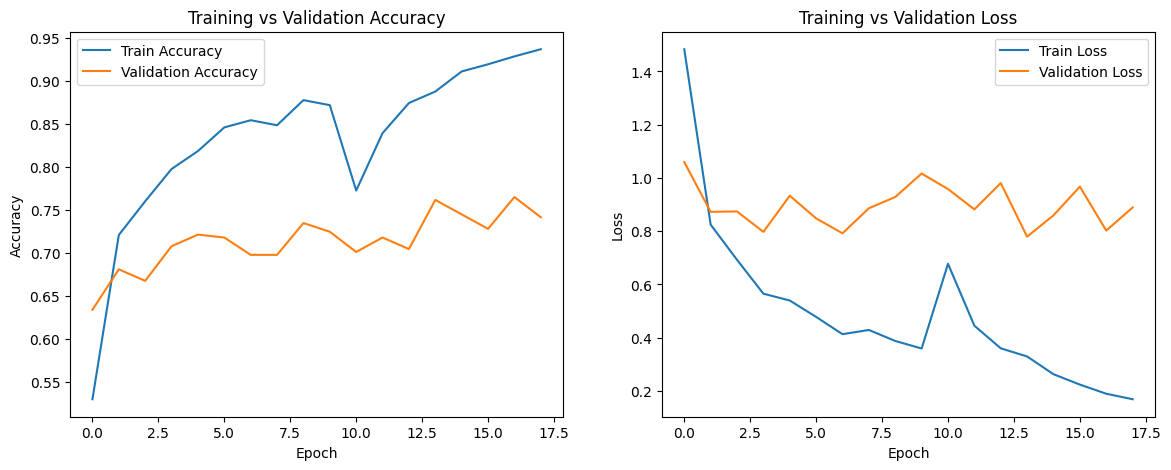

In [14]:
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']

loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


19/19 [==============================] - 15s 652ms/step


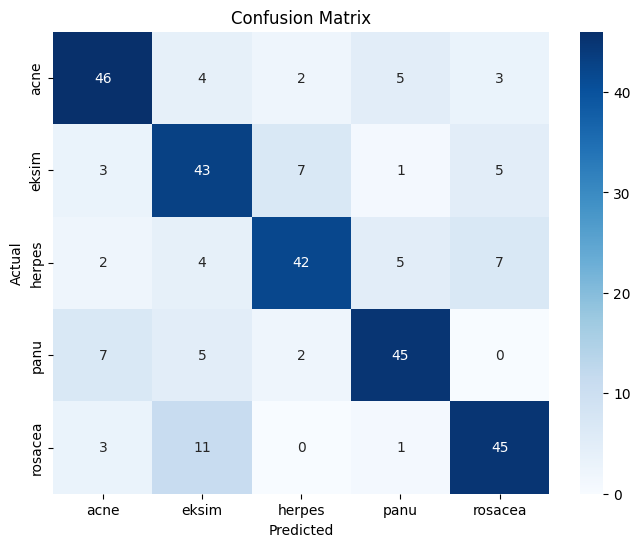

In [15]:
y_true = val_gen.classes
y_pred = np.argmax(model.predict(val_gen), axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [16]:
print(classification_report(y_true, y_pred, target_names=class_names))


              precision    recall  f1-score   support

        acne       0.75      0.77      0.76        60
       eksim       0.64      0.73      0.68        59
      herpes       0.79      0.70      0.74        60
        panu       0.79      0.76      0.78        59
     rosacea       0.75      0.75      0.75        60

    accuracy                           0.74       298
   macro avg       0.75      0.74      0.74       298
weighted avg       0.75      0.74      0.74       298



In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet import preprocess_input


In [18]:
class_names = ['acne', 'eksim', 'herpes', 'panu', 'rosacea']
IMG_SIZE = (224, 224)


In [19]:
def predict_single_image_show(img_path, threshold=0.6):
    # Read image
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print("❌ Image path incorrect")
        return

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, IMG_SIZE)

    # Preprocess for model
    img_input = np.expand_dims(img_resized, axis=0)
    img_input = preprocess_input(img_input)

    # Predict
    probs = model.predict(img_input)[0]
    pred_idx = np.argmax(probs)
    confidence = probs[pred_idx]

    # Decide label
    if confidence < threshold:
        label_text = "Uncertain – Consult Dermatologist"
        conf_text = f"{confidence*100:.2f}%"
    else:
        label_text = class_names[pred_idx]
        conf_text = f"{confidence*100:.2f}%"

    # Show image with prediction
    plt.figure(figsize=(5,5))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"Prediction: {label_text}\nConfidence: {conf_text}",
              fontsize=12, color="green" if confidence >= threshold else "red")
    plt.show()

    # Also print text output
    print("Prediction:", label_text)
    print("Confidence:", conf_text)


1/1 [==============================] - 2s 2s/step


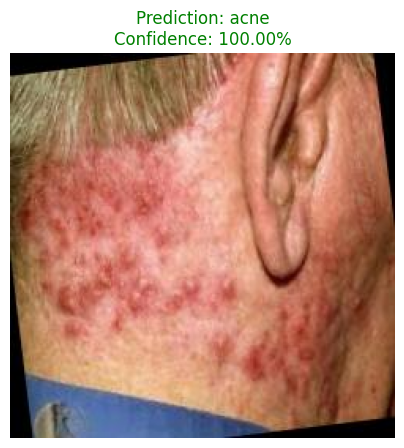

Prediction: acne
Confidence: 100.00%


In [20]:
predict_single_image_show(r"Downloads/Face_dataset/train/acne/ac2_jpg.rf.0e1e8be157ed37ef4c5c5c5375dd672f.jpg")


1/1 [==============================] - 0s 120ms/step


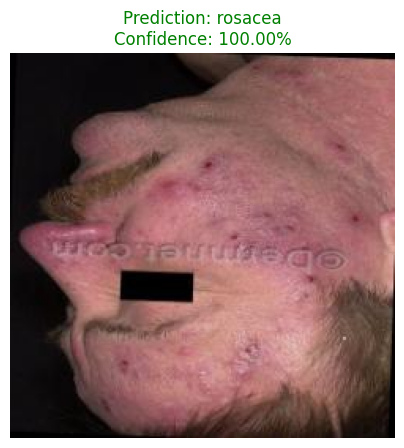

Prediction: rosacea
Confidence: 100.00%


In [22]:
predict_single_image_show(r"Downloads/Face_dataset/train/rosacea/ro2_jpg.rf.29acbf5fd1ab9470a2290a9acfeebac9.jpg")


In [23]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


In [ ]:
# Get true labels and prediction probabilities
y_true = val_gen.classes
y_prob = model.predict(val_gen)

# Binarize labels
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

plt.figure(figsize=(8,6))

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr, tpr,
        label=f"{class_names[i]} (AUC = {roc_auc:.2f})"
    )

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve (Face Disease Classification)")
plt.legend()
plt.grid()
plt.show()


12/19 [=================>............] - ETA: 4s